
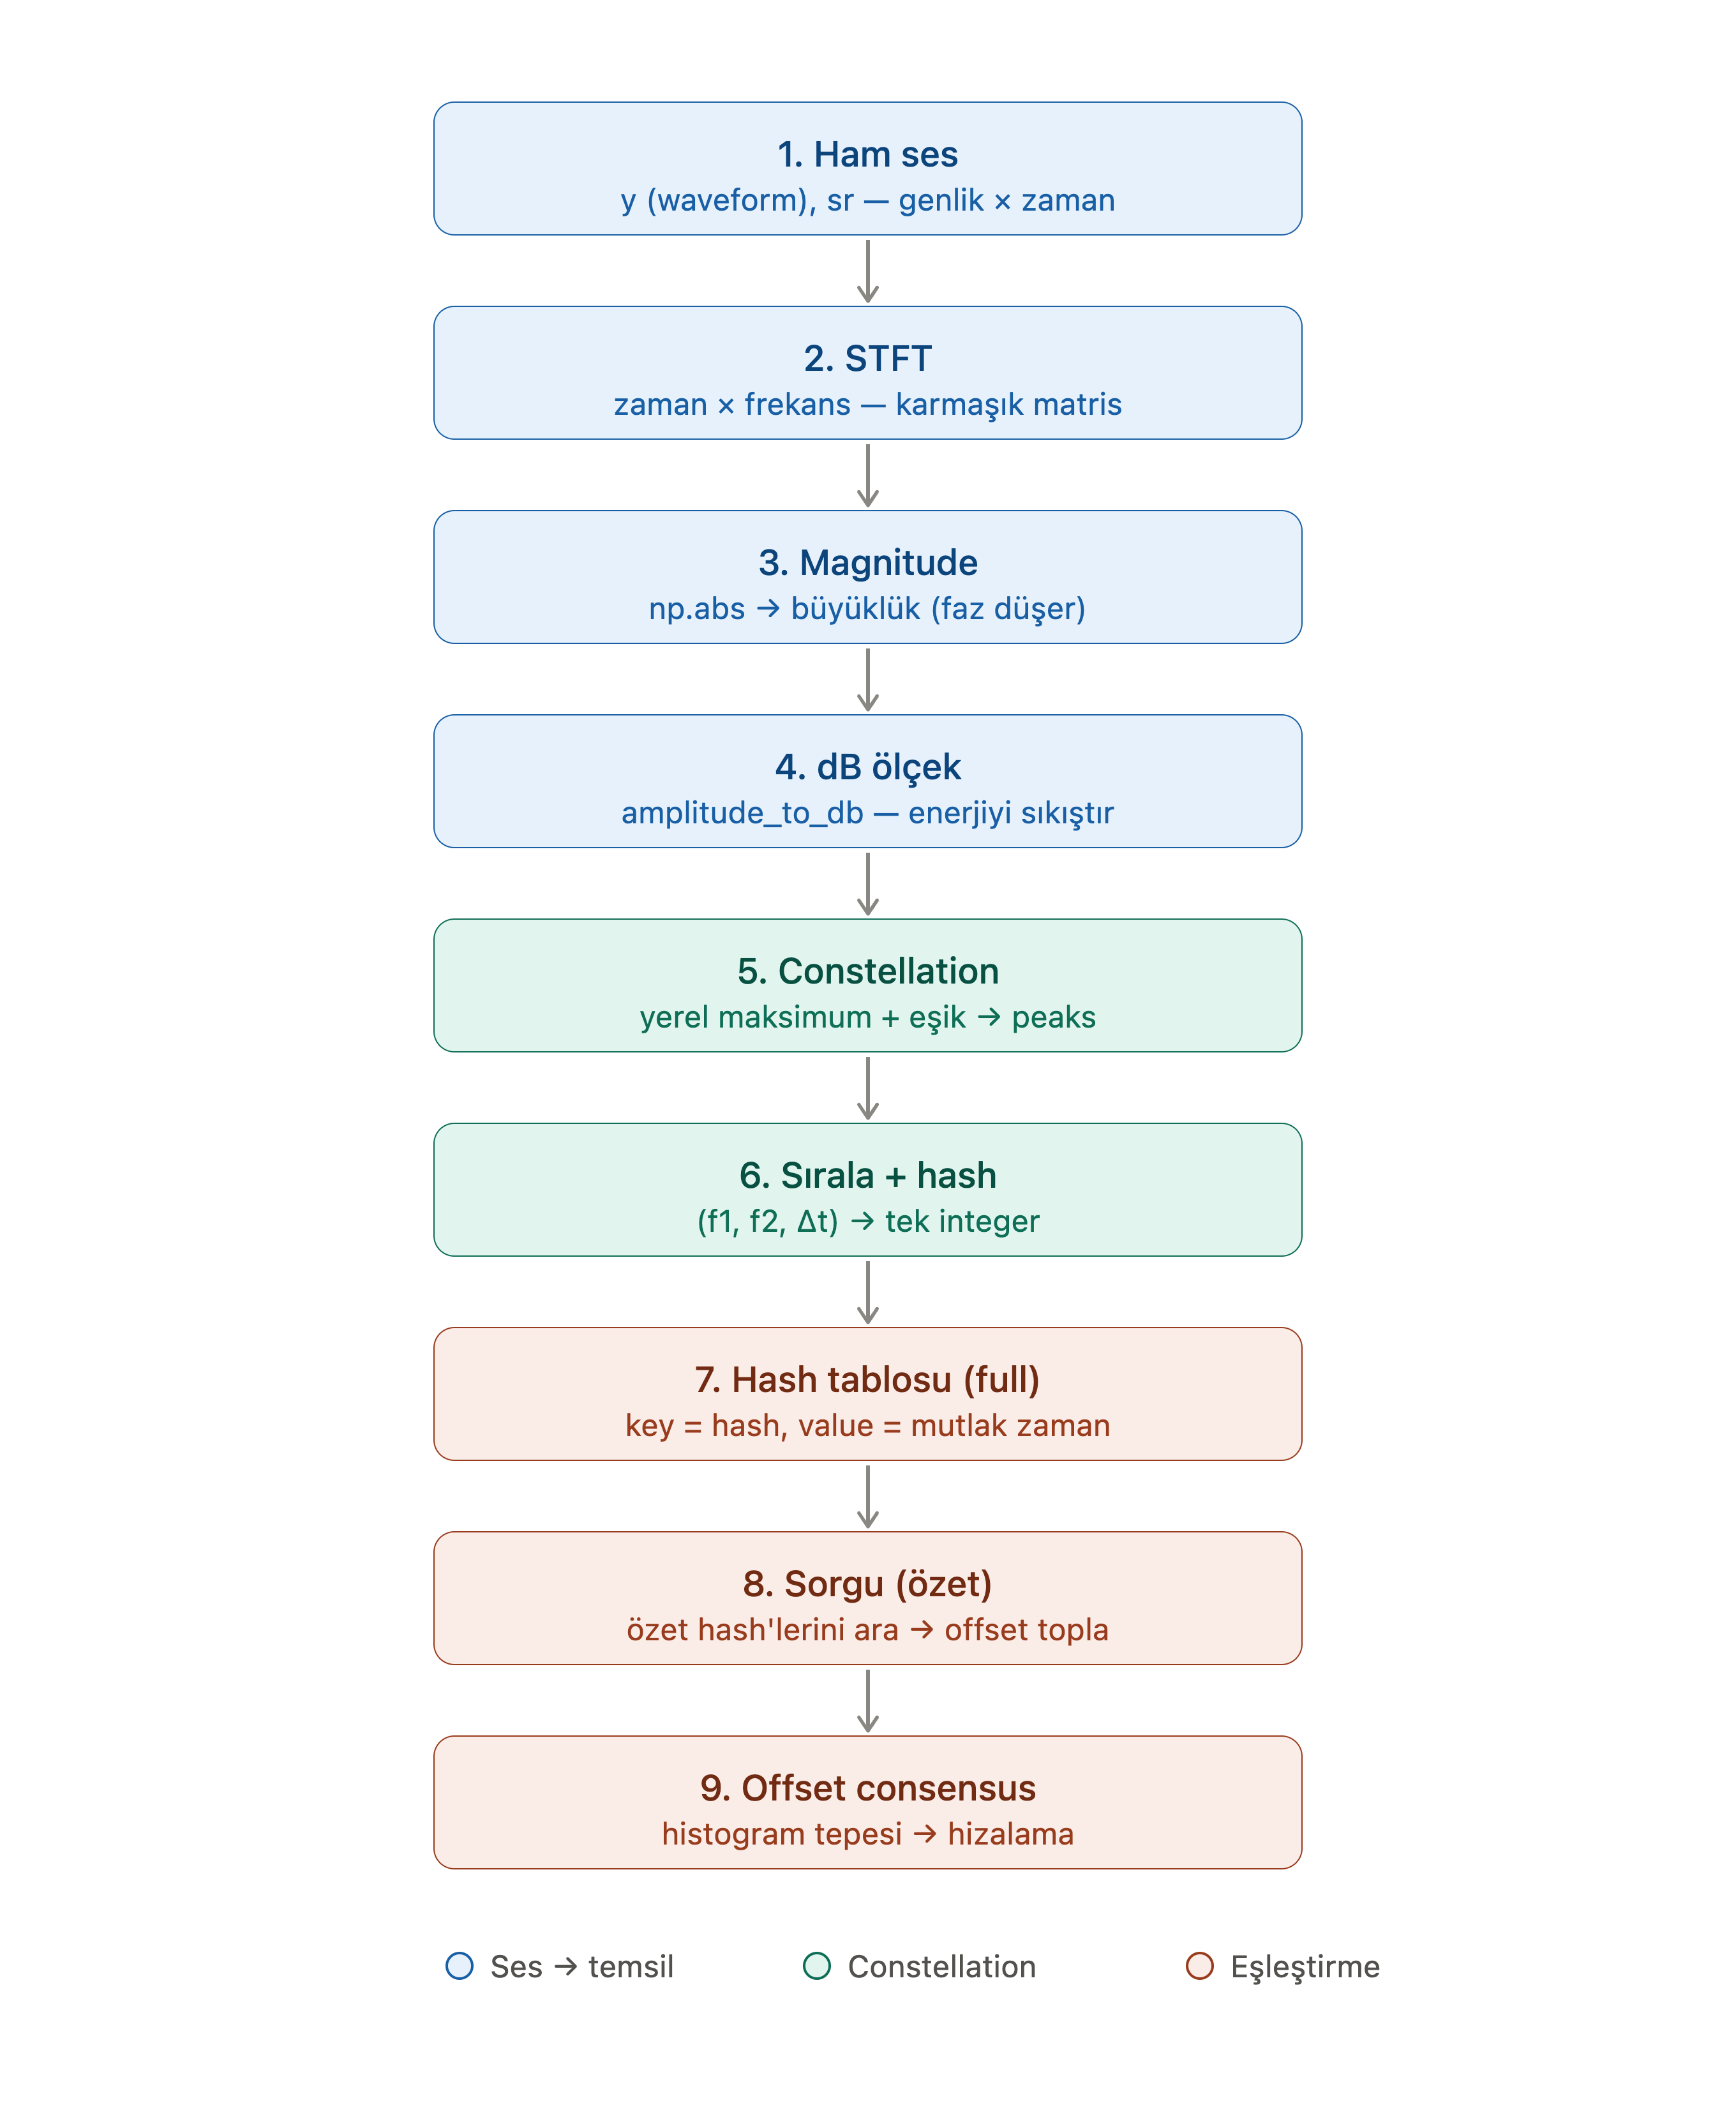

## Ne yapıyoruz ?
Elimizde 90 dk'lık bir maç ve özet videosunun özet sesleri var. Amacımız özetteki her an, maçın tamamının zaman ekseninde tam olarak nereye düşüyor onu tespit etmek. Bunu milisaniye hassasiyetinde ve re-encoding dayanıklı bir biçimde yapmamız gerekiyor.

Peki neden sesi hizalamaya çalışıyoruz ?

Görüntü 4 boyutlu bir veridir - Genişlik x Yükseklik x Renk Kanalı x Zaman - ve pikselleri işlemesi inanılmaz derece yoğun bir matris operasyonu gerektirir. Oysa ses ise tek boyutludur - Genlik x Zaman -. Yani sesin tek boyutlu olması onu görüntüye kıyasla çok daha kolay bir şekilde işlenir kılıyor.

Yayıncılık dünyasında videolar arşivlenirken veya özet haline getirilirken agresif video codecleriyle - H.264, H.265 - tekrar tekrar sıkıştırılır. (re-encoding). Bu durumda pikselleri bozar, renk uzaylarını kaldırır ve görüntünün doğasını değiştirir. Ancak ses codecleri- AAC, MP3 - daha güclü bir sesin gölgede bıraktığı daha zayıf sesleri atarken ( psikoakustik maskeleme), spikerin bağırdığı veya tribünün patladığı o "ana" frekansları neredeyse birebir korur. Bilgi zaten seste, özellikle de enerjinin tepe yaptığı noktalardır. Bu yüzden sadece tepe noktalarını - peak - sececeğiz.

## Neden Ham Dalga Değil ? - waveform

Ham ses dalgasını - waveform - bir dizi sayı olarak düşünebiliriz. İki ses dosyasını üst üste koyup kaydırarak nerede eşleştiğini bulmak - cross correlation - O(n x m) karmaşıklığa sahiptir.

 - n: 90 dakikalık maçın sample sayısı
 - m: 5 dakikalık özetin sample sayısı

bunu hesaplamak saatler sürer. Ayrıca sesde gain %10 bile artmış olsa veya ses mili-saniyeler düzeyinde faz kaymasına uğramışsa bu sample'lar birbirini tutmaz. Ayrıca hız sorunun yanı sıra, waveform birebir aynı varsayımına dayanır. Re-encode sample değerini değiştirir, gain tüm genliklerini kaydırır, faz kayması hizayı bozar. Yani hız çözülse bile waveform yaklaşımı re-encode'a dayanmaz.

**Bize genlikten (sesin yüksekliğinden) bağımsız, yapısal bir kimlik (fingerprint) gerekir**

Peki, yapısal kimlikten kastımız nedir ? - **frekans içeriğinin zamanla değişimi.**

## STFT: zaman - frekans ekseni

Sesi zamana karşı genlik olarak değil, zamana karşı frekans enerjisi olarak görmemiz gerekir. Bunun yolu da STFT - **Short Time Fourier Transform** -işlemidir.

Sesi küçük pencelere - örn. 2048 sample'lık dilimlere - böleriz. Her bir pencerenin Fourier dönüşümünü alıp o anki pencerenin frekans içeriğini çıkarırız. Yani her pencere bir frekans spektrumu verir. Bu pencereleri sesin üzerinde kaydırarak - örn. 512 sample atlayarak (hop_length) - koca bir spektrogram matrisi elde ederiz.

Kritik Tasarım Kararı (Heisenberg İlkesi):
Pencereyi (window size - n_fft) büyük seçersen, frekansları çok net ayrıştırırsın ama olayın "ne zaman" gerçekleştiği bulanıklaşır (zaman çözünürlüğü düşer). Pencereyi dar tutarsan, zamanı çok iyi tutturursun ama hangi frekans olduğunu bilemezsin. Hizalama işleminde milisaniye hassasiyeti istediğimiz için, bu iki parametrenin dengesi kuracağın sistemin ilk önemli ayarı olacaktır.

**Spektrogram, bir ses sinyalinin zaman içinde hangi frekanslardan oluştuğunu gösteren görsel bir temsilidir.**

Peki neden saf Fourier değil de STFT ?

Klasik Fourier tüm sese birden uygulanırsa "seste hangi frekanslar var" sorusunu cevaplar ama bu frekansların ne zaman olduklarını yok eder — 2. saniyedeki bas ile 4. saniyedeki tiz aynı torbaya girer, sıra kaybolur. Hizalama için "frekans ne zaman" tam da işimizin özü. STFT bu yüzden var: sesi parçalara bölüp her parçaya ayrı Fourier uygulayarak hem frekansı hem zamanı birlikte korur.

## Constellation Map (Seyrekleştirme)

Spektrogram elimizde yoğun bir ısı haritası olarak durur. Ancak tüm bu bilgiler bize lazım değildir. Shazam'ında temelini oluşturan fikir:

Bu iki boyutlu haritada (Zaman ve Frekans) etrafındaki tüm piksellerden daha parlak olan (local maximum) noktalarını bul ve geri kalan tüm veriyi çöpe at.

Peki bu yöntem neden çalışır ? Çünkü lossy (kayıplı) ses algoritmaları "Psikoakustik Maskeleme" kullanır. Yani yüksek sesli bir frekansın yanındaki sessiz frekansları siler. Biz sadece tepe noktalarını (peak) alarak, sıkıştırma algoritmalarının dokunmadığı en sağlam veriye ulaşmış olacağız. Sonunda elimizde hafif ve seyrek bir nokta bulutu kalacaktı. Bu yoğun nokta bulutuna constellation map denir ve finger-print'in iskeletini oluşturacaktır.

## Combinatorial Hashing - Parmak İzi Yaratma

Tek bir tepe noktası ayırt edici değildir. Pek çok anda benzer frekansta enerjiler vardır. Ayırt ediciliğini artırmak için nokta çiftleri kullanırız.

Haritada bir tepe noktası seçer (Anchor), onun biraz ilerisindeki ve belirli bir frekans aralığındaki (Target Zone) başka bir nokta ile eşleştirirsin. Target zone iki parametreyle tanımlanır: anchor'dan ne kadar ileriye bakılacağı (zaman penceresi) ve anchor başına kaç hedefle eşleşileceği (fan-out).

Elde ettiğimiz veri şudur:

[Anchor frekansı, Hedef Frekans, Aralarındaki Zaman Farkı]

Bu üçlü kombinasyonu tek bir sayıya (Hash) dönüştürürüz. Üçlü (f1, f2, Δt) tek bir f'ten çok daha benzersizdir, bu yüzden iki farklı sesin aynı hash'i üretme (collision) olasılığı düşüktür — ama sıfır değildir. Bir anchor için kaç tane hedef seçeceğin benim parmak izi veritabanının boyutu ve hızını belirler.

Yukarıda ki üçlü içerisinde mutlak zaman yoktur. Sadece 2 frekans ve aralarındaki göreli zaman farkı vardır. Bu yuzden aynı ses deseni, 100. saniyede de 50000. saniyede de olsa aynı hash'i üretir. Mutlak zaman hash tablosunda hash tablosunun value kısmında korunur.

## Offset Consensus - Uzlaştırma ile Eşleştirme

Diyelim ki özet videodan çıkardığımız bir hash, maçın tamamında hash veritabanında 30 farklı yerlerde eşleşti. Hangisinin doğru olduğunu nasıl bulacağız ?

Gerçekten doğru eşleşmenin bir koşulu vardır: **Aralarındaki zaman farkı her zaman sabittir.**

  - Tam maçtaki zaman: $t_{ref}$
  - Özet videodaki zaman: $t_{query}$
  - Fark (Offset): $t_{ref} - t_{query}$

Eğer özet videodaki 15.saniye, tam maçtaki 300. saniyeden alınmışsa, özetin 16. saniyesi tam maçın 301. saniyesine denk gelmek zorundadır.


yani 300 - 15 = 301 - 16 = 285. Doğru olan tüm eşleşmelerin offset değeri 285'tir. Tüm bu offset değerlerini bir histograma koyduğumuzda, sahte eşleşmeler zeminde dümdüz bir gürültü oluştururken, gerçek eşleşmelerin olduğu offset değerinde devasa bir tepe (spike) oluşuracaktır. İşte o tepe noktası, milisaniyesi milisaniyesine senin hizalama noktanı verir.

Pratikte bu zamanlar saniye değil STFT frame indeksi cinsindendir. Bulunan offset'i saniyeye çevirmek için offset × hop_length / sr kullanılır.


### Librosa

librosa, python da ses analizi için yazılmış bir kütüpanedir. - library for audio -.

Ham ses dosyalarını alıp, üzerinde çalışılabilir sayısal temsillere çevirir ve bu temsiller üzerinden yaygın sinyal işleme operasyonlarını tek satırda sunar.


### Waveform

Ses havadaki bir basınç dalgasıdır. Bir davula vurduğunda zar titrer, havayı sıkıştırıp gevşetir, bu sıkışma-gevşeme dalgası kulağına ulaşır. Yani ses özünde "havanın basıncının zamanla yukarı-aşağı salınması"dır. Waveform, bu basınç değerinin zaman içindeki değişiminin sayısal kaydıdır. Yani "her an hava ne kadar sıkışmış/gevşemiş" bilgisinin bir dizi hâli.

In [33]:
import librosa
import IPython

filename = librosa.example("trumpet")

# y -> sesi waveform olarak yükler. o an ölçülen basınç genliği.


# sr -> örnekleme oranı olarak kaydeder.
# Gerçek ses sürekli (analog) bir dalgadır, zamanda sonsuz noktası vardır.
# bu sonsuz dalgayı saklayabilmek için belirli aralıklarla örnekler alırız.
# Sample rate = saniyede kaç ölçüm alındığı. Birimi Hz.
y, sr = librosa.load(filename)

print(y.shape) # librosa.load default olarak sesi mono'ya çevirir. (N,) dizi verir.
print(sr) # librosa.load default olarak sesi 22050 Hz'ye örnekler.

# y.shape[0] -> toplam ölçüm sayısı, sr -> saniyedeki ölçüm
print(y.shape[0] / sr) # saniye cinsinden video uzunlugu - sanity check

IPython.display.Audio(y, rate=sr) # dinlemek için


(117601,)
22050
5.333378684807256


waveform tek başına anlamsızdır — "elimde 117601 sayı var" dersin ama bunların ne kadar zamana yayıldığını bilmezsin. sr olmadan y'yi ne çalabilir, ne de süresini bilebilir, ne de frekans hesabı yapılabilir.

### STFT: Short Time Fourier Transform

waveform bize her an ki genliği söyler fakat bizim ihtiyacımız bu anda hangi frekanslar çalıyor olduğu. Çünkü bir sesin kimliği, genlik değerinde değil, frekans içeriğinde yaşar.

Fourier'in temel fikri ise her ses, saf tonların toplamıdır. Yani karmaşık bir dalga, farklı frekanslardaki basit bir sinüs dalgalarının toplamı olarak yazılabilir.

Örn. bir orkestra çalıyor ve havada tek bir karışık dalga var, bu waveform'dur.
Ama o dalga aslında 400 Hz keman, 100 Hz bas, 8000 Hz zil'in hepsinin üst üste binmesinden oluşur. Fourier bu karışımı geri ayırır.

Çıktısı bir spektrumdur. Yatayda frekans, dikeyde ise o frekansın ne kadar güçlü olduğunu gösterir.

Fakat saf Fourier dönüşümü zamanı ortadan kaldırır. Örn, ses önce 2 saniye 100 Hz bas, sonra 5000 Hz tiz çalsın. Saf Fourier bize bu ayrışmayı verir fakat hangisin önce hangisinin sonra çaldığını tamamen kaybeder, sanki herşey aynı anda çalıyormuş gibi olur. Bizim ses kimliği için bu felakettir.

Bunun çözümü ise STFT'dir. Yani tüm sese birden Fourier uygulamak yerine, sesi küçük parçalara böl ve her parçayı ayrı ayrı Fourier uygula. Böylece her küçük parça için bu kısa an aralığında hangi frekans vardı bilgisini alabiliriz.

Mekanizma:

 1. Sesin başına küçük bir pencere koy (n_fft = 512 samplık bir dilim olsun.)
 2. O pencere içindeki ses Fourier uygula. O pencere için bir spektrum çıkar. Bu spektrogramın bir sütunu olur.
 3. Pencereyi bir miktar kaydır (hop_length=128 olsun) ve tekrarla, bir sonraki sütun oluşur.
 4. Pencere sonuna gelene kadar devam ederiz.

Sonuçta her sütun bir "an"ın frekans fotoğrafı, sütunları yan yana dizince zaman-frekans haritası — yani spektrogram ortaya çıkar.

Yani özetle:

**STFT: Sesi kısa pencerelere bölüp her pencereye Fourier uygulayarak, "hangi frekans, ne zaman, ne kadar" bilgisini birlikte veren bir zaman-frekans dönüşümü.**

In [2]:
STFT = librosa.stft(y, n_fft = 512, hop_length=128)
print(STFT.shape) # (257, 919)
# 919 sütun = pencereyi 919 kez kaydırdın (919 zaman frame'i)
# 257 satır = her pencerenin Fourier'i 257 frekans bandı

# 257 nasıl bulunur ?
# n_fft / 2 + 1 -> frekans bin sayısı

(257, 919)


Peki n_fft yani pencere boyutu seçimi nasıl olacak ?

Bu bir ikilemdir ve pek de bir kaçış yolu yok. Yani:
  - Geniş Pencere: İçinde çok sample var, Fourier frekansı ince ayırt eder → frekans çözünürlüğü iyi. Ama pencere zamanda geniş bir aralığı kapsar, "bu frekans tam olarak ne zaman?" bulanıklaşır → zaman çözünürlüğü kötü.

  - Dar Pencere: Zamanda dar bir aralığa bakar, olayın ne zaman olduğunu keskin yakalar → zaman çözünürlüğü iyi. Ama içinde az sample var, Fourier frekansı kabaca ayırır → frekans çözünürlüğü kaba.

Burada bir tasarım kararı yapacağız. Yüksek zaman hassasiyeti mi yoksa frekans hassasiyeti mi ?

Bize hizalama için olayın tam ne zaman olduğu kritik olduğundan, biz zaman hassasiyetini seçtik, biraz daha dar bir pencere kullandık.

In [3]:
STFT[0, :3]

array([ 0.002192  +0.j, -0.00149843+0.j, -0.0037924 +0.j], dtype=complex64)

STFT'nin çıktısı bir karmaşık sayıdır:  a + bj

Çünkü her frekans için Fourier 2 şey verir:
  
  1. Büyüklük: o frekanstan ne kadar var ( √(a²+b²))
  2. Faz: o dalganın o andaki konumu/kayması (açı)

Sesin kimliği için bize sadece büyüklük lazım. Faz'la işimiz yok.
Bildiğimiz üzere mutlak değer bir noktanın sıfıra olan uzaklığını verir.

abs(-6) = 6, abs(3) = 3 iken, karmaşık sayılarda da mutlak değer orijine olan uzaklığı verir. yani :

|a + bj| = √(a² + b²)

Yani np.abs fonksiyonu karmaşık bir sayıya uygulandığında o noktanın orjinden ne kadar uzakta olduğunu yani büyüklük(magnitude) verir. Yukarıda da bahsettiğimiz gibi STFT 2 bilgi taşır:

- Büyüklük = orijine uzaklık = √(a²+b²) → o frekanstan ne kadar var
- Faz = o noktanın açısı (düzlemde hangi yönde durduğu) → dalganın konumu

mutlak değer sayesinde açıdan kurtuluyoruz.

In [4]:
import numpy as np

stft_magnitude = np.abs(STFT)
print(stft_magnitude.shape)
print(stft_magnitude[0, :3])
print(stft_magnitude.dtype)

(257, 919)
[0.002192   0.00149843 0.0037924 ]
float32


Bu şekilde görselleştirmeye çalışırsak muhtemelen anlamlı bir görüntü elde edemeyiz. Çünkü ses enerjisi çok büyük bir aralığa yayılır. Büyük değerler çok büyük, küçük değerler ise çok küçük olabilir.

Bunun çözümü ise logaritmik ölçek - yani desibel -. İnsan kulağı zaten sesi logaritmik algılar, bu yüzden ses şiddeti desibeldir. Logaritma geniş aralığı sıkıştırır böylece çok yüksek değerler ve çok küçük değerleri aynı görüntüde görebiliriz.



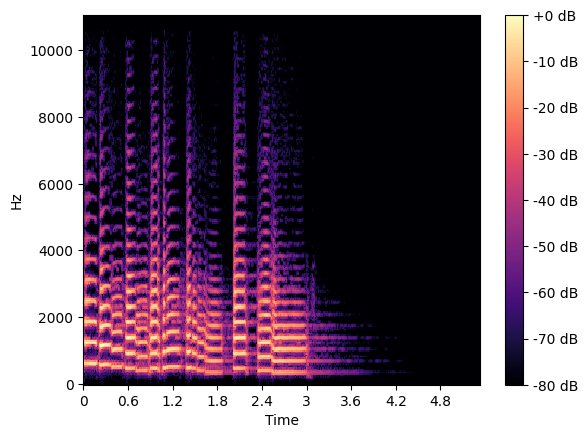

In [5]:
import matplotlib.pyplot as plt


# db'ye geçiş
stft_db = librosa.amplitude_to_db(stft_magnitude, ref=np.max(stft_magnitude))
# ref=np.max(stft_magnitude) => en yüksek değeri 0 db kabul eder. Geri kalan herşey ona göre
# negatif dB kalır. Bu yüzden peak eşiği negatif bir sayıdır ve
# bu ancak dB ölçeğinde anlamlıdır.


# spektogram
img = librosa.display.specshow(stft_db, sr=sr, hop_length=128, x_axis='time', y_axis='hz')
plt.colorbar(img, format='%+2.0f dB')
plt.show()

Bu yoğun spektrogram'dan en ayırt edici tepe noktalarını bulup gerisini atacağız. (Constellation map). Yani elde edeceğimiz şey, 919 sütunluk yoğun bir matris yerine düzlemde serpilmiş birkaç yüz (zaman, frekans) noktası.

Peki Peak veya Local Maximum nedir ? Bir hücrenin peak olabilmesi için etrafındaki komşularından daha güçlü olması gerekir. Peki hangi komşular ?

Bunu bir komşuluk penceresi tanımlayarak yaparız. ±f frekans, ±t zaman içindeki bölge. Eğer bu hücre bu bölgedeki tüm hücrelerden büyükse veya eşitse o bir lokal maximumdur. -> Peak

bu komşuluk parametresi de fine-tune edebileceğimiz bir parametredir. Constellation ne kadar sık olursa gürültü ve maliyet artar, seyrek olursa da eşleşme bulamaz.



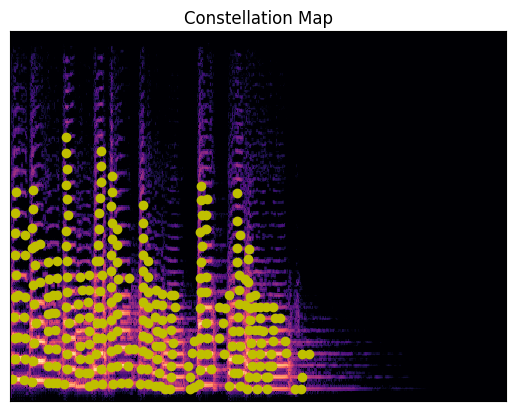

In [6]:
import scipy

# maximum_filter ->
constellation_matrix = scipy.ndimage.maximum_filter(stft_db, size=10) # size çok peak varsa büyüt, çok azsa küçült.
mask = (stft_db == constellation_matrix)  & (stft_db > -40) # peak noktaları true geri kalan false
# 40 değeri değişebilir. - orta, üzmez bir değer.

peaks = np.argwhere(mask) # peak noktaları
# np.argwhere(mask) her peak için [frekans_bin, zaman_frame] verir

# gorsellestirme
img = librosa.display.specshow(stft_db, sr=sr, hop_length=128)
plt.scatter(peaks[:,1], peaks[:, 0], c="y")
plt.title("Constellation Map")
plt.show()

Constellation map hazır, şimdi hashing kısma geçebiliriz. Fakat önce birkaç kritik ön hazırlığı halletmeliyiz.

ilk olarak peak'leri zamana göre sıralayacağız.
peaks = np.argwhere(mask) bize çıktı olarak frekans öncelikli bir sıralı verdi, fakat biz bunu zaman sıralı olmasını istiyoruz.

peaks = np.argwhere(mask) bize maskede True olan her hücrenin koordinatını verir. Her koordinat 2 sayıdan oluşur.

peaks[:, 0] -> frekans bin indexleri

peaks[:, 1] -> zaman frame indexi

Yani [ 11, 100] -> 11. frekans bin'inde, 100. zaman frame'inde bir peak var demektir. Yani önce frekans, sonra zaman gelir.

In [16]:
sorted_peaks = np.argsort(peaks[:, 1]) # değer değil, index döndürür
peaks = peaks[sorted_peaks] # index döndürdüğü için tüm listeye uygularız.
print(peaks[: 10])


[[ 15   4]
 [ 58   7]
 [ 72   8]
 [101   8]
 [ 43   8]
 [130   8]
 [ 29   9]
 [116   9]
 [ 87  10]
 [145  11]]


peak'leri zamana göre sıraladık. hash'in özü şuydu, her peak'i bir anchor yap, onun ileri zaman yönündeki peak'leri target olarak eşle.

burada 2 tasarım parametresi var:

  - zaman penceresi - Δt aralığı: anchor ne kadar ileriye kadar target arayacak ? bunu Δt_max ve Δt_min ile belirleyeceğiz.
  - Fan-out: bir anchor, target zone'undaki peaklerin hepsiyle mi yoksa ilk N tanesiyle mi eşleşsin ? Hepsiyle eşleşmek hash sayısını artırır. Genelde bir üst sınır konur.

In [17]:
t_min = 1
t_max = 50
fan_out = 5
print("örnek bir peak noktası: ", peaks[0])
print("anchor zamanı: ", peaks[0][1])
print("anchor frekansı: ", peaks[0][0])

t_anchor = peaks[0][1]

target_zone = peaks[
    (peaks[:, 1] >= t_anchor + t_min) &
    (peaks[:, 1] <= t_anchor + t_max)
]
target_zone = target_zone[: fan_out]

target_zone



örnek bir peak noktası:  [15  4]
anchor zamanı:  4
anchor frekansı:  15


array([[ 58,   7],
       [ 72,   8],
       [101,   8],
       [ 43,   8],
       [130,   8]])

target_zone[:fan_out]: target zone'daki ilk 5 peak'i alır — peak'ler zaman-sıralı olduğu için bunlar "zamanca en yakın 5 target." Makul bir fan-out stratejisi; ileride "en güçlü 5" ya da "en çeşitli 5" gibi değiştirilebilir.

elimiz de bir anchor ve onun target'ları var.

Şimdi her (anchor, target) çifti için o üçlüyü oluşturacağız. (f1, f2, Δt).
Bu üçlü, iki peak arasındaki ilişkiyi tanımlayan konum-bağımsız bir imzadır. İçinde mutlak zaman yoktur, sadece 2 frekans ve aralındaki göreli fark Δt vardır. Bu yüzden aynı ses deseni kaydın neresinde olursa olsun aynı üçlüyü üretir. Bu üçlüden bir hash değeri üretip paketleyeceğiz.


f1 = anchor frekansı

f2 = target frekansı ( targetin 0. sütunu)

Δt = target zamanı - anchor zamanı ( target[1] - t_anchor)


Önemli bir not: t_anchor (mutlak zaman) bu üçlü içerisinde değildir. üçlü içerisinde sadece Δt var. Mutlak zaman, hash tablosunda value olarak tutulacak, bu üçlüden üretilen hash değeri ise key olarak.

In [9]:
f1 = peaks[0][0]
f2 = target_zone[:, 0]
del_t = target_zone[:, 1] - t_anchor

xx = []

for tf, dt in zip(f2, del_t):
  xx.append((f1, tf, dt))

for i in xx:
  print(i)

(np.int64(15), np.int64(58), np.int64(3))
(np.int64(15), np.int64(72), np.int64(4))
(np.int64(15), np.int64(101), np.int64(4))
(np.int64(15), np.int64(43), np.int64(4))
(np.int64(15), np.int64(130), np.int64(4))


Şimdi hashing gereği bu üç sayıyı tek bir sayıya sıkıştıracağız. Çünkü hash tablosunda anahtar olarak tek bir sayı ararız. Sıkıştırmayı bu formülü kullanarak yapacağız.:

- hash = f1 × 2¹⁵ + f2 × 2⁶ + Δt


Burdaki üstellerin anlamı nedir ?

- f1,f2 frekans bin'idir. maksimum 256 alabilir ve 257 farklı bin olabilir (0-256). 256'yı temsil etmek için kaç bit gerekir ? 2^8 = 256. Burada 9 bit güvenli alıyoruz.

- Δt zaman farkıdır. maksimum t_max = 50 olarak tanımlamıştık. 50 sayısını 2^6 ile temsil edebiliriz.


Yani bitlerin yerleşimine baktığımızda Δt en küçük değer oldukları için en alttaki bitlere otururlar. hemen üstüne f2 kaydırılır yani 2^6. en üste de f1 kalır yani 2^15. hash = (f1 << 15) | (f2 << 6) | del_t

Kritik kural: her alanın kendi bölgesine ayrılan bit, o alanın maksimum değerini taşıyabilecek kadar geniş olmalı — yoksa alanlar birbirine taşar (overflow), farklı üçlüler aynı hash'i üretir (istenmeyen collision).

In [19]:
hash = []

for i in xx:
  anchor_freq = i[0]
  target = i[1]
  delta_t = i[2]

  hash.append(
          (((anchor_freq << 15) | (target << 6) | delta_t), t_anchor) # direkt olarak matematik işlemi de olur
  ),
hash

[(np.int64(495235), np.int64(4)),
 (np.int64(496132), np.int64(4)),
 (np.int64(497988), np.int64(4)),
 (np.int64(494276), np.int64(4)),
 (np.int64(499844), np.int64(4))]

In [20]:
# bütün değerler için hash table

t_min = 1
t_max = 50
fan_out = 5

hash_table = {}

for anchor in peaks:
  t_anchor = anchor[1]
  f1 = anchor[0]


  filtered_peaks = peaks[
      (peaks[:, 1] >= t_anchor + t_min) & (peaks[:, 1] <= t_anchor + t_max)
  ]
  filtered_peaks = filtered_peaks[: fan_out]

  for target in filtered_peaks:
    f2 = target[0]
    del_t = target[1] - t_anchor
    hash_value = (((f1 << 15) | (f2 << 6) | del_t))

    hash_table.setdefault(hash_value, []).append(t_anchor)



In [21]:
list(hash_table.items())
# ilk değer hash, ikinci  değeri (anahtar, değer)

[(np.int64(495235), [np.int64(4)]),
 (np.int64(496132), [np.int64(4)]),
 (np.int64(497988), [np.int64(4)]),
 (np.int64(494276), [np.int64(4)]),
 (np.int64(499844), [np.int64(4)]),
 (np.int64(1905153), [np.int64(7), np.int64(26)]),
 (np.int64(1907009), [np.int64(7)]),
 (np.int64(1903297), [np.int64(7)]),
 (np.int64(1908865), [np.int64(7)]),
 (np.int64(1902402),
  [np.int64(7), np.int64(26), np.int64(269), np.int64(422)]),
 (np.int64(2361153), [np.int64(8), np.int64(27)]),
 (np.int64(2366721), [np.int64(8)]),
 (np.int64(2364866), [np.int64(8)]),
 (np.int64(2368579), [np.int64(8)]),
 (np.int64(2363974), [np.int64(8)]),
 (np.int64(3311425), [np.int64(8)]),
 (np.int64(3316993), [np.int64(8)]),
 (np.int64(3315138), [np.int64(8)]),
 (np.int64(3318851), [np.int64(8)]),
 (np.int64(3314246), [np.int64(8)]),
 (np.int64(1410881), [np.int64(8)]),
 (np.int64(1416449), [np.int64(8)]),
 (np.int64(1414594), [np.int64(8)]),
 (np.int64(1418307), [np.int64(8)]),
 (np.int64(1413702), [np.int64(8)]),
 (np.i

Hem maçın 90 dakika tamamı hem de özet için hash değerleri üreteceğimiz için bir fonksiyonunu yazalım.
90 dakika maçın tamamı için bir hash table üretip, özet hash değerini o tablo içerisinde arayacağız.


In [13]:
def fingerprint(peaks, t_min, t_max, fan_out):
  """peaks (zaman-sıralı) -> (hash, mutlak_zaman) çiftleri listesi.
Hem full hem özet için çağrılır."""
  pairs = []
  for anchor in peaks:
    t_anchor = anchor[1]
    f1 = anchor[0]

    target_zone = peaks[
        (peaks[:, 1] >= t_anchor + t_min) & (peaks[:, 1] <= t_anchor + t_max)
    ]

    target_zone = target_zone[:fan_out]

    for target in target_zone:
      f2 = target[0]
      del_t = target[1] - t_anchor

      hash_value = (((f1 << 15) | (f2 << 6) | del_t))
      pairs.append( (hash_value, t_anchor) )
  return pairs



In [14]:
cift = fingerprint(peaks, 1, 50, 5)
cift[: 5]

[(np.int64(495235), np.int64(4)),
 (np.int64(496132), np.int64(4)),
 (np.int64(497988), np.int64(4)),
 (np.int64(494276), np.int64(4)),
 (np.int64(499844), np.int64(4))]

Ses kimliği oluşturmamız tamam. ayrıca full maç peak noktalarını çıkarmıştık. aynısını özet bir ses için de yapacağız.

elimizde sentetik bir veri olduğu için özetini rastgele saniyelerden üreteceğiz. 1.5 sn - 2.5 sn arası özet olsun.


Özeti ham y'den kesip sıfırdan STFT/dB yapmıyoruz — bunun yerine full'ün zaten hesaplanmış stft_db matrisinden dilimliyoruz. Neden: özet ayrı işlenirse farklı normalizasyon (ref) ve farklı STFT ızgarası oluşur, aynı ses farklı dB/peak üretir, hash'ler tutmaz (4/453 eşleşme felaketi). stft_db'den dilimleyince özet, full ile birebir aynı normalizasyon ve ızgaradan gelir → hash'ler tutar. Bu, sentetik testin en temiz kurulumu.

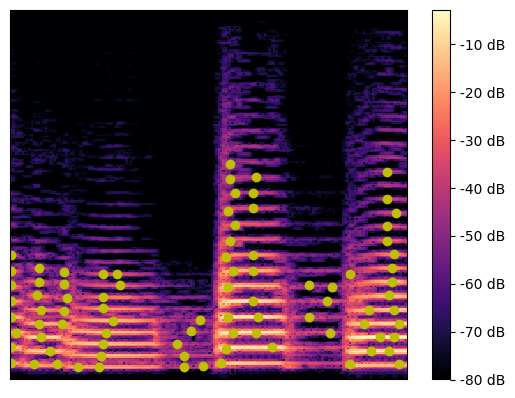

In [22]:

baslangic = 1.5
bitis = 2.5

ozet_db_matris = stft_db[:, 258:430] # 1.5 - 2.5 sn arası


# consellation_matrix

ozet_cons = scipy.ndimage.maximum_filter(ozet_db_matris, size=10)
ozet_mask = (ozet_db_matris == ozet_cons) & (ozet_db_matris > -40)

ozet_peaks = np.argwhere(ozet_mask)


# görsellestirelim


img = librosa.display.specshow(ozet_db_matris, sr=sr, hop_length=128)
plt.scatter(ozet_peaks[:, 1], ozet_peaks[:, 0], c = "y")
plt.colorbar(img, format="%+2.0f dB")
plt.show()



Özetin de peak noktalarını çıkardık. şimdi sorgu ve offset hesaplaması yapacağız.

ilk olarak özetin peaklarini zaman domain'de sıralacağız ve daha sonra fingerprint fonksiyonuna sokacağız.



In [26]:
sorted_ozet_peaks = np.argsort(ozet_peaks[:, 1])
ozet_peaks = ozet_peaks[sorted_ozet_peaks]
print(ozet_peaks[:10])

[[11  0]
 [22  0]
 [54  0]
 [43  0]
 [65  0]
 [75  0]
 [86  0]
 [32  2]
 [10 10]
 [58 11]]


In [27]:
highlight_cift = fingerprint(ozet_peaks, 1, 50, 5)
highlight_cift[:10]

[(np.int64(362498), np.int64(0)),
 (np.int64(361098), np.int64(0)),
 (np.int64(364171), np.int64(0)),
 (np.int64(364748), np.int64(0)),
 (np.int64(362892), np.int64(0)),
 (np.int64(722946), np.int64(0)),
 (np.int64(721546), np.int64(0)),
 (np.int64(724619), np.int64(0)),
 (np.int64(725196), np.int64(0)),
 (np.int64(723340), np.int64(0))]

In [28]:
full_cift = fingerprint(peaks, 1, 50, 5)
full_cift[:10]

# full_ciftlerimizi tabloya cevirip içerisinde özet çiftlerini arayacağız.
# cunku bu cıktıyı doğrudan arama için kullanamayız.
# bir hash'i bulmak kabus olur

[(np.int64(495235), np.int64(4)),
 (np.int64(496132), np.int64(4)),
 (np.int64(497988), np.int64(4)),
 (np.int64(494276), np.int64(4)),
 (np.int64(499844), np.int64(4)),
 (np.int64(1905153), np.int64(7)),
 (np.int64(1907009), np.int64(7)),
 (np.int64(1903297), np.int64(7)),
 (np.int64(1908865), np.int64(7)),
 (np.int64(1902402), np.int64(7))]

In [29]:
hash_table = {}

for (hash, zaman) in full_cift:
  hash_table.setdefault(hash, []).append(zaman)


Şimdi full hash_tablosu içerisinde özet hashleri arayıp bulduklarımızı offset hesabı yapabiliriz.



In [30]:
offset_list = []

for (hash_, ozet_zamani) in highlight_cift:
  if hash_ in hash_table:
    for full_zaman in hash_table[hash_]:
      offsett = full_zaman - ozet_zamani
      offset_list.append(offsett)

len(offset_list)

390

389 tane eşleşen hash değerimiz var. şimdi offset histogramı çizip ground-truth doğrulaması yapabiliriz.

yani, bu 398 offset'in içinde 258 civarında keskin bir tepe olmalı (kestiğin başlangıç frame'i). Onu bulacağız.

In [31]:
from collections import Counter
offset_sayac = Counter(offset_list)
offset_sayac.most_common(5) # en cok tekrar eden offset

[(np.int64(258), 346),
 (np.int64(411), 8),
 (np.int64(105), 8),
 (np.int64(407), 3),
 (np.int64(117), 2)]

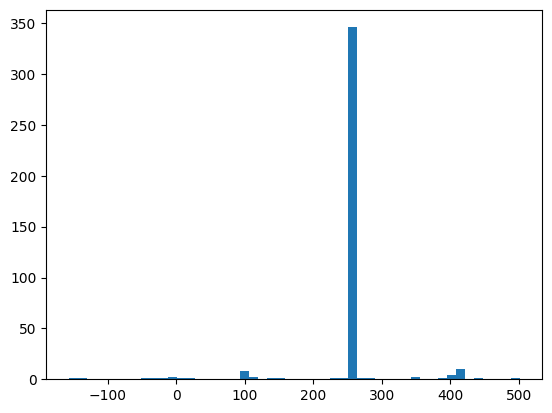

In [32]:
plt.hist(offset_list, bins=50)
plt.show()

(a) gerçek özet ayrı dosya olacağı için S_'den dilimleyemeyeceksin — o zaman ref'i sabitleme ve fan-out artırma stratejileri devreye girecek; (b) Katman 4 (RANSAC/monotoniklik) bu offset'i alıp gürültülü gerçek eşleşmelerde temiz segmentlere çevirecek.